In [1]:
from src.data_loader import download_data


In [2]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "SPY", "JPM", "NVDA", "TSLA"]

data = download_data(tickers)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


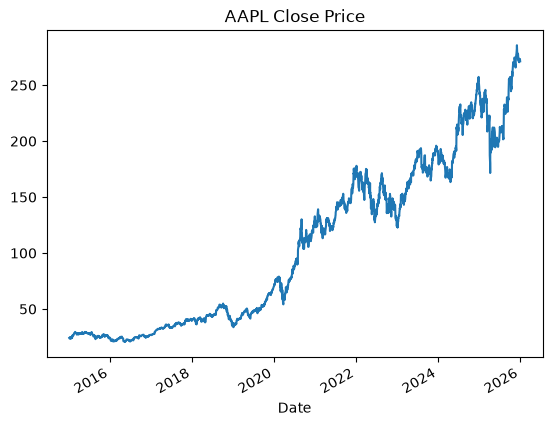

In [3]:
import matplotlib.pyplot as plt
data["AAPL"]["Close"].plot(title="AAPL Close Price")
plt.show()

In [4]:
print(data["AAPL"].dtypes)

Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


In [5]:
print(data["AAPL"].head())

Price           Close       High        Low       Open     Volume
Date                                                             
2015-01-02  24.192598  24.659500  23.754462  24.648436  212818400
2015-01-05  23.511063  24.042136  23.325188  23.962475  257142000
2015-01-06  23.513271  23.772169  23.152583  23.575230  263188400
2015-01-07  23.842976  23.942551  23.610630  23.721271  160423600
2015-01-08  24.759087  24.816620  24.053201  24.170481  237458000


In [6]:
print(data["AAPL"].columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')


In [7]:
print(data["AAPL"].columns.tolist())

['Close', 'High', 'Low', 'Open', 'Volume']


In [8]:
from src.features import add_features, add_label

aapl = data["AAPL"].copy()
aapl = add_features(aapl)
aapl = add_label(aapl)
aapl = aapl.dropna().reset_index(drop=True)

print(aapl.shape)
print(aapl[["Close", "return_1d", "sma_ratio", "rsi_14", "volatility_10d", "label"]].head(10))

(2712, 17)
Price      Close  return_1d  sma_ratio     rsi_14  volatility_10d  label
0      27.758129   0.011004   1.052928  32.710818        0.012886      1
1      28.222429   0.016727   1.047804  45.533458        0.014304      0
2      28.540113   0.011256   1.043801  44.971673        0.014748      0
3      28.324615  -0.007551   1.040959  47.391334        0.013869      0
4      27.969179  -0.012549   1.037187  41.765684        0.014503      0
5      28.260197   0.010405   1.034551  44.733046        0.014851      0
6      28.144676  -0.004088   1.033772  45.400317        0.013086      0
7      27.409351  -0.026127   1.032239  42.884018        0.014582      1
8      27.600395   0.006970   1.029627  44.626589        0.013523      1
9      27.380465  -0.007968   1.027017  41.320812        0.013587      1


In [9]:
print(aapl["label"].value_counts())

label
1    1563
0    1149
Name: count, dtype: int64


In [10]:
from src.model import walk_forward_train

preds, fold_results = walk_forward_train(aapl)

for i, r in enumerate(fold_results):
    print(f"Fold {i+1}: accuracy={r['accuracy']:.3f}, precision={r['precision']:.3f}")

Fold 1: accuracy=0.482, precision=0.659
Fold 2: accuracy=0.582, precision=0.640
Fold 3: accuracy=0.580, precision=0.563
Fold 4: accuracy=0.535, precision=0.555
Fold 5: accuracy=0.538, precision=0.566


In [11]:
from src.backtest import generate_signals, run_backtest

aapl_signals = generate_signals(aapl, preds)
pf = run_backtest(aapl_signals)

print(pf.stats())

Start                                             453
End                                              2711
Period                             2259 days 00:00:00
Start Value                                   10000.0
End Value                                34912.480892
Total Return [%]                           249.124809
Benchmark Return [%]                       912.318917
Max Gross Exposure [%]                          100.0
Total Fees Paid                           6238.313847
Max Drawdown [%]                             36.49533
Max Drawdown Duration               360 days 00:00:00
Total Trades                                      168
Total Closed Trades                               167
Total Open Trades                                   1
Open Trade PnL                             -34.912481
Win Rate [%]                                54.491018
Best Trade [%]                              28.900919
Worst Trade [%]                            -22.351522
Avg Winning Trade [%]       

In [12]:
import numpy as np

buy_hold_returns = aapl["Close"].pct_change().dropna()
buy_hold_sharpe = np.sqrt(252) * buy_hold_returns.mean() / buy_hold_returns.std()
print(f"Buy & Hold Sharpe Ratio: {buy_hold_sharpe:.3f}")

Buy & Hold Sharpe Ratio: 0.879


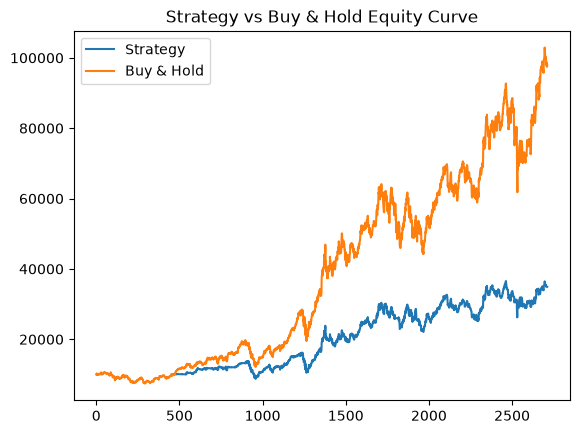

In [13]:
import matplotlib.pyplot as plt

pf.value().plot(label="Strategy")
(aapl["Close"] / aapl["Close"].iloc[0] * 10000).plot(label="Buy & Hold")
plt.legend()
plt.title("Strategy vs Buy & Hold Equity Curve")
plt.savefig("data/equity_curve.png")
plt.show()

In [16]:
from src.features import add_features, add_label
from src.model import walk_forward_train
from src.backtest import generate_signals, run_backtest
import numpy as np
import pandas as pd

summary = []

for ticker in data.keys():
    df = data[ticker].copy()
    df = add_features(df)
    df = add_label(df)
    df = df.dropna().reset_index(drop=True)

    preds, fold_results = walk_forward_train(df)
    df_signals = generate_signals(df, preds)
    pf = run_backtest(df_signals)

    buy_hold_returns = df["Close"].pct_change().dropna()
    buy_hold_sharpe = np.sqrt(252) * buy_hold_returns.mean() / buy_hold_returns.std()
    buy_hold_total_return = (df["Close"].iloc[-1] / df["Close"].iloc[0] - 1) * 100

    summary.append({
        "ticker": ticker,
        "strategy_return_%": pf.stats()["Total Return [%]"],
        "benchmark_return_%": buy_hold_total_return,
        "strategy_sharpe": pf.stats()["Sharpe Ratio"],
        "benchmark_sharpe": buy_hold_sharpe,
        "win_rate_%": pf.stats()["Win Rate [%]"],
        "max_drawdown_%": pf.stats()["Max Drawdown [%]"]
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

ticker  strategy_return_%  benchmark_return_%  strategy_sharpe  benchmark_sharpe  win_rate_%  max_drawdown_%
  AAPL         249.124809          879.370469         0.792608          0.878957   54.491018       36.495330
  MSFT         275.924303         1264.563862         0.868409          1.039314   62.051282       33.645120
 GOOGL         553.927637         1027.858135         1.100035          0.922568   65.277778       34.125399
  AMZN         334.501878         1143.551654         0.808751          0.877320   61.764706       63.370882
   SPY         173.958077          297.193103         0.858000          0.807372   53.521127       33.717259
   JPM         109.709713          604.828892         0.543883          0.803283   52.525253       49.662949
  NVDA        3740.210979        34097.985384         1.304485          1.350580   64.473684       57.787487
  TSLA        1542.589771         3621.716772         1.019989          0.868125   49.645390       72.743373
